# Experiment 5
###Implement a Flow-Based Generative Model using a Deep Learning Framework

### **Core Idea:**

We transform a simple distribution:

z ~ Normal(0,1)

into a complex data distribution using invertible mappings.

If transformation is reversible, we can compute probability density.

In [ ]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

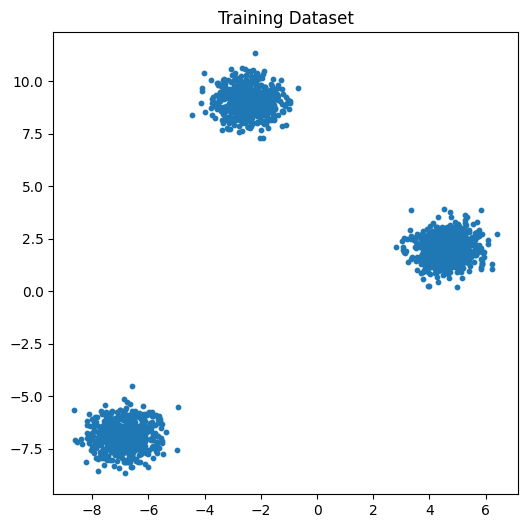

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=3, cluster_std=0.6, random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=10)
plt.title("Training Dataset")
plt.show()

In [ ]:
# convert to tensor
X_train = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
class CouplingLayer(Model):

    def __init__(self):
        super().__init__()

        self.net = tf.keras.Sequential([
            layers.Dense(64, activation='relu'),
            layers.Dense(64, activation='relu'),
            layers.Dense(2)
        ])

    def call(self, x):

        x1 = x[:, :1]
        x2 = x[:, 1:]

        params = self.net(x1)

        scale = tf.tanh(params[:, :1])
        shift = params[:, 1:]

        y1 = x1
        y2 = x2 * tf.exp(scale) + shift

        log_det = tf.reduce_sum(scale, axis=1)

        y = tf.concat([y1, y2], axis=1)

        return y, log_det

In [ ]:
flow = [CouplingLayer() for _ in range(4)]
optimizer = tf.keras.optimizers.Adam(0.0001)

def log_prob_standard_normal(z):

    return -0.5 * tf.reduce_sum(z**2 + np.log(2*np.pi), axis=1)

In [ ]:
def forward_flow(x):

    log_det_total = 0
    z = x

    for layer in flow:
        z, log_det = layer(z)
        log_det_total += log_det

    return z, log_det_total

In [ ]:
@tf.function
def train_step(batch):

    with tf.GradientTape() as tape:

        z, log_det = forward_flow(batch)

        log_prob = log_prob_standard_normal(z) + log_det

        loss = -tf.reduce_mean(log_prob)

    variables = []

    for layer in flow:
        variables += layer.trainable_variables

    grads = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(grads, variables))

    return loss

In [ ]:
losses = []

epochs = 500

for epoch in range(epochs):

    loss = train_step(X_train)
    losses.append(loss.numpy())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.numpy():.4f}")

Epoch 0, Loss = 101.0406
Epoch 50, Loss = 22.9360
Epoch 100, Loss = 18.8747
Epoch 150, Loss = 17.8218
Epoch 200, Loss = 17.3706
Epoch 250, Loss = 17.1261
Epoch 300, Loss = 16.9745
Epoch 350, Loss = 16.8728
Epoch 400, Loss = 16.8006
Epoch 450, Loss = 16.7465


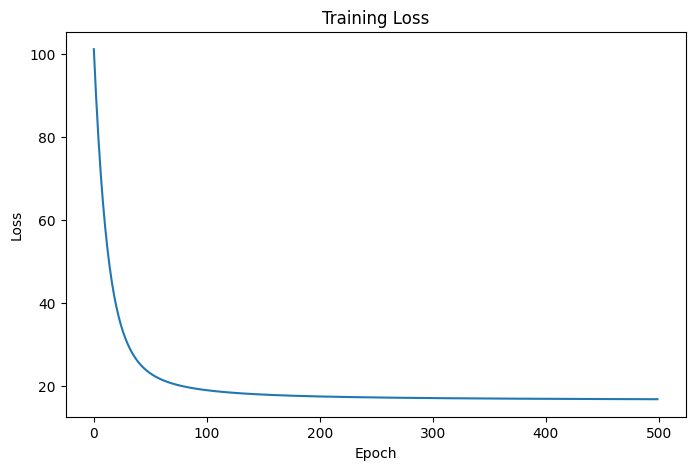

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
z = np.random.normal(size=(2000,2)).astype(np.float32)
samples = tf.convert_to_tensor(z)

generated = samples

for layer in flow:
    generated, _ = layer(generated)

generated = generated.numpy()

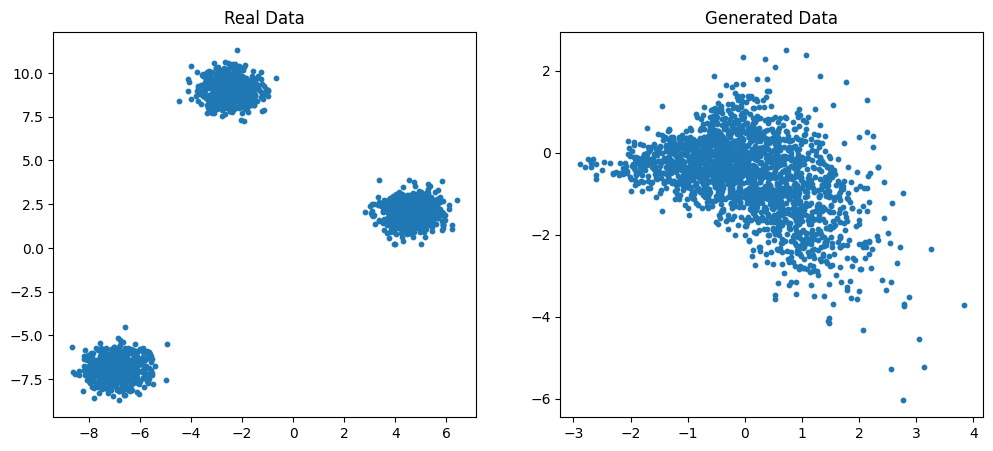

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], s=10)
plt.title("Real Data")

plt.subplot(1,2,2)
plt.scatter(generated[:,0], generated[:,1], s=10)
plt.title("Generated Data")

plt.show()